In [223]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import sympy as sp
from sympy import sin, cos, exp
import pandas as pd

C:\Users\adria\AppData\Local\Temp\ipykernel_17576\2290345347.py:2: RuntimeWarning: divide by zero encountered in log
  return theta_c/2 * (1-u**2) + theta/2 * ((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))
C:\Users\adria\AppData\Local\Temp\ipykernel_17576\2290345347.py:2: RuntimeWarning: invalid value encountered in multiply
  return theta_c/2 * (1-u**2) + theta/2 * ((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))


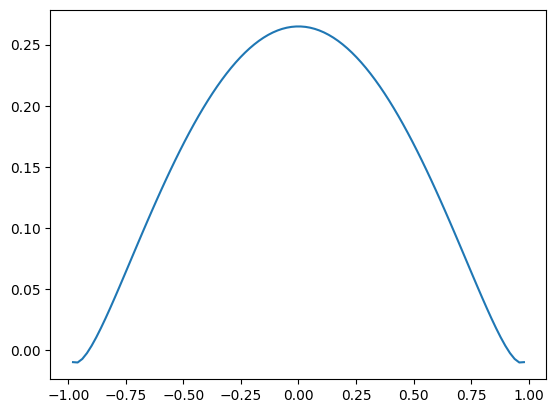

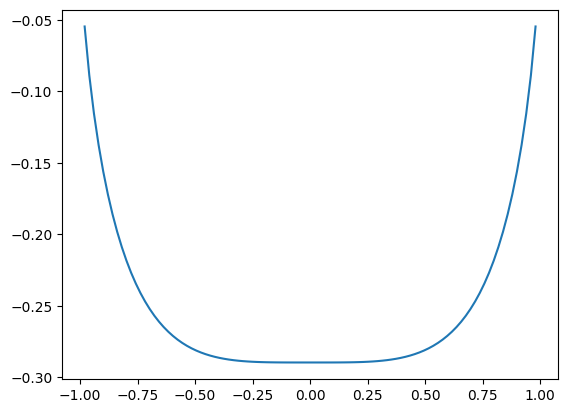

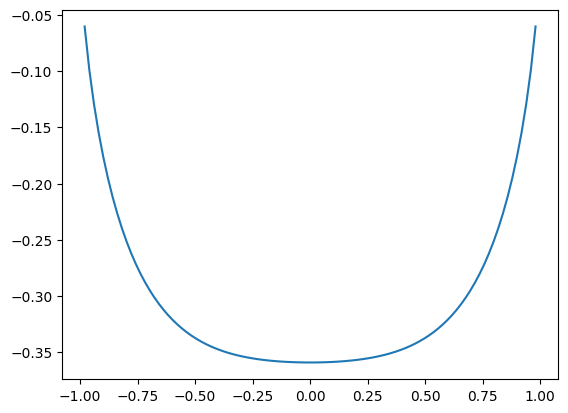

In [224]:
def F(u,theta,theta_c):
    return theta_c/2 * (1-u**2) + theta/2 * ((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))

u = np.linspace(-1,1,100)
theta = np.array([0.7,1.5,1.6])
theta_c = 1.5

for i in range(len(theta)):
    plt.plot(u,F(u,theta[i],theta_c))
    plt.show()

Oppgave 1:

a) Observerer at ved lavere temperaturer en kritisk temperatur, vil energien i systemet minimeres dersom konsentrasjonene legger seg i potensialbrønner delt av en potensialbarriere. Dette betyr at det er konsentrasjonforskjell mellom de to fasene. Dersom vi er ved eller over kritisk temperatur, finnes det ikke lengre noen potensialbarriere og energien i systemet er minimal dersom konsentrasjon er 0 og vi har fullstendig blanding mellom fasene.

b) Den tidsderiverte, laplaceoperatoren og den harmoniske operatoren er lineære operatorer. De består kun av derivasjon og addering som er lineære operasjoner. f(-u) = -f(u) kan enkelt og vil bevises.

c) Gjort forhånd

In [225]:

def biharmonic_solver(X,Y,F,c,Lx,Ly,Nx,Ny,mean = 0.0):

    F_hat = fft2(F)

    kx = fftfreq(Nx,d=Lx/Nx)*2*np.pi
    ky = fftfreq(Ny,d=Ly/Ny)*2*np.pi
    KX , KY = np.meshgrid(kx,ky,sparse=True)

    K2 = KX**2 + KY**2
    K4 = K2**2

    K4[0,0] = 1

    U_hat = F_hat / (K4 + c)

    U_hat[0,0] = mean * Nx * Ny

    return U_hat

def manufacture_solution(u_str,c):

    x,y = sp.symbols('x y')
    u_sy = sp.sympify(u_str)
    laplace = lambda u: sp.diff(u,x,x) + sp.diff(u,y,y)
    f_sy = sp.sympify(laplace(laplace(u_sy))+c*u_sy)
    f = sp.lambdify((x,y),f_sy,modules='numpy')
    u = sp.lambdify((x,y),u_sy,modules='numpy')
    return f,u

In [226]:
Lx = 2*np.pi
Ly = 4*np.pi

Nx_list = np.array([4,8,15,16,20,32])

u_str_1 = "sin(8*(1-x))*cos(4*y)"
c = 1
f_1,u_exact_1 = manufacture_solution(u_str_1,c)
EOC_list = np.zeros(len(Nx_list)-1)
error_list = np.zeros(len(Nx_list))

for i in range(len(Nx_list)):
    Nx = Nx_list[i]
    Ny = 2*Nx
    x = np.linspace(0,Lx,Nx,endpoint=False)
    y = np.linspace(0,Ly,Ny,endpoint=False)
    X,Y = np.meshgrid(x,y,sparse=True)
    F = f_1(X,Y)
    U_hat = biharmonic_solver(X,Y,F,c,Lx,Ly,Nx,Ny)
    U = ifft2(U_hat).real

    error = np.linalg.norm(U - u_exact_1(X,Y),np.inf)
    error_list[i] = error

EOC_list = np.log(error_list[:-1]/error_list[1:])/np.log((Lx/Nx_list[:-1])/(Lx/Nx_list[1:]))
EOC_list = np.insert(EOC_list,0,np.inf)

df = pd.DataFrame({'Nx':Nx_list,'error':error_list,'EOC':EOC_list})
df

,Nx,error,EOC
0,4,3.957433e+00,inf
1,8,1.892177e+02,-5.579338
2,15,4.913842e+00,5.807813
3,16,5.595524e-14,497.474685
4,20,4.120038e-13,-8.947067
5,32,1.225797e-12,-2.319800


In [227]:
k = np.arange(0,10)
Nx_list = 4+4*k

u_str_2 = "exp(sin(x)**2+cos(2*y))"
c = 0
f_2,u_exact_2 = manufacture_solution(u_str_2,c)
EOC_list = np.zeros(len(Nx_list)-1)
error_list = np.zeros(len(Nx_list))

for i in range(len(Nx_list)):
    Nx = Nx_list[i]
    Ny = 2*Nx
    x = np.linspace(0,Lx,Nx,endpoint=False)
    y = np.linspace(0,Ly,Ny,endpoint=False)
    X,Y = np.meshgrid(x,y,sparse=True)
    F = f_2(X,Y)
    U_exact_2 = u_exact_2(X,Y)
    mean = np.mean(U_exact_2)
    U_hat = biharmonic_solver(X,Y,F,c,Lx,Ly,Nx,Ny,mean)
    U = ifft2(U_hat).real

    error = np.linalg.norm(U - U_exact_2,np.inf)
    error_list[i] = error

EOC_list = np.log(error_list[:-1]/error_list[1:])/np.log((Lx/Nx_list[:-1])/(Lx/Nx_list[1:]))
EOC_list = np.insert(EOC_list,0,np.inf)

df = pd.DataFrame({'Nx':Nx_list,'error':error_list,'EOC':EOC_list})
df

,Nx,error,EOC
0,4,4.283095e+01,inf
1,8,5.623272e+01,-0.392756
2,12,9.039969e+00,4.508016
3,16,4.207284e-01,10.662547
4,20,1.395357e-02,15.264846
5,24,5.752609e-04,17.489249
6,28,2.764803e-05,19.690274
7,32,1.317656e-06,22.793890
8,36,5.928637e-08,26.330027
9,40,2.508363e-09,30.018351
